# 📝 E-commerce customer churn analysis

## 🌟 Highlights 
From this project "E-commerce customer churn analysis", the highlights are addressed as:

## ℹ️ Project Introduction 
The general meaning of churn is that customers stop using the service provided by the companies.  
Churn analysis in e-commerce website is a commonly used technique to analyze and predict customers' behavior.  
From the analysis outcome, e-commerce companies can perform some actions, such as reach out potential churn customers to prevent profit loss or analyze common traits for product/service improvement

## 🎯 Mission & Goal
- Build a churn prediction model to predict customer churn

## 🏭 Build Flow
- EDA
- Model training
- Model evaluation
- Follow-up action recommendation

## Import libraries

In [3]:
import time

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_auc_score, 
    average_precision_score, # This is the PR score
    accuracy_score
)

## EDA

**Columns introduction**
- CustomerID: Unique customer ID
- Churn: Churn Flag
- Tenure: Tenure of customer in organization
- PreferredLoginDevice: Preferred login device of customer
- CityTier: City tier
- WarehouseToHome: Distance in between warehouse to home of customer
- PreferredPaymentMode: Preferred payment method of customer
- Gender: Gender of customer
- HourSpendOnApp: Number of hours spend on mobile application or website
- NumberOfDeviceRegistered: Total number of deceives is registered on particular customer
- PreferedOrderCat: Preferred order category of customer in last month
- SatisfactionScore: Satisfactory score of customer on service
- MaritalStatus: Marital status of customer
- NumberOfAddress: Total number of added added on particular customer
- Complain: Any complaint has been raised in last month
- OrderAmountHikeFromlastYear: Percentage increases in order from last year
- CouponUsed: Total number of coupon has been used in last month
- OrderCount: Total number of orders has been places in last month
- DaySinceLastOrder: Day Since last order by customer
- CashbackAmount: Average cashback in last month

In [4]:
# df_col_discription = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='Data Dict')
# df_col_discription.columns = df_col_discription.iloc[0]
# df_col_discription = df_col_discription.iloc[1:]
# df_col_discription['Total'] = df_col_discription['Variable'] + ': ' + df_col_discription['Discerption']
# for i in list(df_col_discription['Total']):
#     print(i)

In [5]:
df = pd.read_excel('E Commerce Dataset.xlsx', sheet_name='E Comm')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [6]:
# CustomerID is useless
df = df.drop(columns=['CustomerID'], axis=1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5366 non-null   float64
 2   PreferredLoginDevice         5630 non-null   object 
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5379 non-null   float64
 5   PreferredPaymentMode         5630 non-null   object 
 6   Gender                       5630 non-null   object 
 7   HourSpendOnApp               5375 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   object 
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   object 
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain          

In [8]:
# Change object column into category column for later use
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Churn                        5630 non-null   int64   
 1   Tenure                       5366 non-null   float64 
 2   PreferredLoginDevice         5630 non-null   category
 3   CityTier                     5630 non-null   int64   
 4   WarehouseToHome              5379 non-null   float64 
 5   PreferredPaymentMode         5630 non-null   category
 6   Gender                       5630 non-null   category
 7   HourSpendOnApp               5375 non-null   float64 
 8   NumberOfDeviceRegistered     5630 non-null   int64   
 9   PreferedOrderCat             5630 non-null   category
 10  SatisfactionScore            5630 non-null   int64   
 11  MaritalStatus                5630 non-null   category
 12  NumberOfAddress              5630 non-null   int64   
 13  Com

Let's see the value in each columns  

**Initial findings**
- Imbalanced dataset in terms of churn
- Almost 20% of people has satisfaction score of 1
- 28% people raised complain last month

In [9]:
for col in df.columns:
    if col == 'CustomerID':
        continue
    else:
        print(f'This is column: {col}')
        print('=========================================')
        print('Value counts')
        print(df[col].value_counts())
        print('-----------------------------------------')
        print('Value counts: Null')
        print(df[col].isna().value_counts())
        print('\n')

This is column: Churn
Value counts
0    4682
1     948
Name: Churn, dtype: int64
-----------------------------------------
Value counts: Null
False    5630
Name: Churn, dtype: int64


This is column: Tenure
Value counts
1.0     690
0.0     508
8.0     263
9.0     247
7.0     221
10.0    213
5.0     204
4.0     203
3.0     195
11.0    194
6.0     183
12.0    182
13.0    181
14.0    176
2.0     167
15.0    159
16.0    149
19.0    140
18.0    123
20.0    109
17.0    106
23.0     89
21.0     84
22.0     76
24.0     75
28.0     70
30.0     66
27.0     66
26.0     60
25.0     59
29.0     55
31.0     49
50.0      1
60.0      1
51.0      1
61.0      1
Name: Tenure, dtype: int64
-----------------------------------------
Value counts: Null
False    5366
True      264
Name: Tenure, dtype: int64


This is column: PreferredLoginDevice
Value counts
Mobile Phone    2765
Computer        1634
Phone           1231
Name: PreferredLoginDevice, dtype: int64
-----------------------------------------
Value c

In [10]:
original_rows = df.shape[0]
remaining_rows = df.dropna(axis=0).shape[0]
print(f'There are {original_rows} rows in total')
print(f'There are {remaining_rows} rows after dropping rows with NaN missing value')

There are 5630 rows in total
There are 3774 rows after dropping rows with NaN missing value


Let's see if city tier affects cashback
- Majority of tier 3 paid slightly more compared to tier 1 and 2
- Profile of tier 1 and tier 2 does not show big difference
- In general, we cannot see clear gap for cashback between each tier 

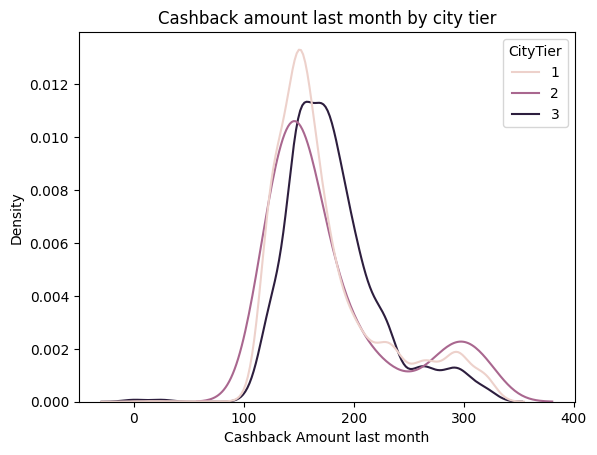

In [11]:
sns.kdeplot(data=df, x='CashbackAmount', hue='CityTier', common_norm=False)
plt.xlabel('Cashback Amount last month')
plt.title('Cashback amount last month by city tier')
plt.show()

Let's see churn result by satisfaction score
- Churn could come from different satisfaction score

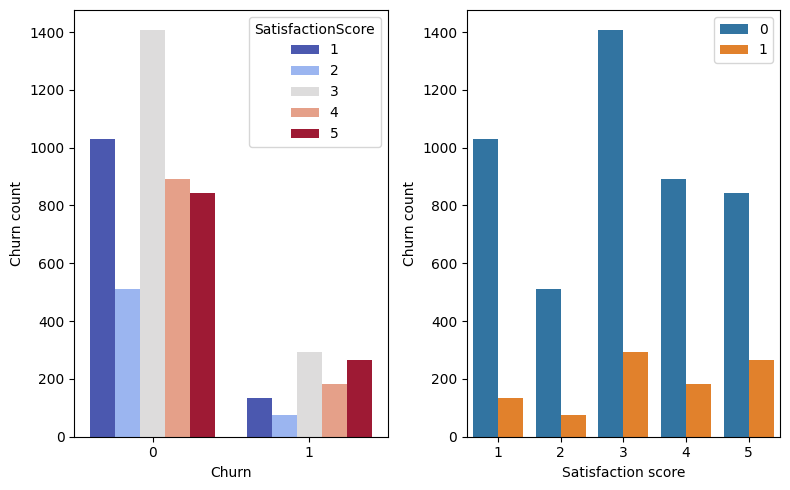

In [12]:
df_churn_satis = df.groupby(['Churn', 'SatisfactionScore'])['Churn'].count().reset_index(name='Churn count')
# print(df_churn_satis)
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
sns.barplot(data=df_churn_satis, x='Churn', y='Churn count', hue='SatisfactionScore', palette='coolwarm', ax=axes[0])
sns.barplot(data=df_churn_satis, x='SatisfactionScore', y='Churn count', hue='Churn', ax=axes[1])
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Churn count')
axes[1].set_xlabel('Satisfaction score')
axes[0].set_ylabel('Churn count')
plt.legend()
plt.tight_layout()
plt.show()

Let's see complain factor per churn
- People who raised complaint have relatively high potion for churn. Complain seems a important factor

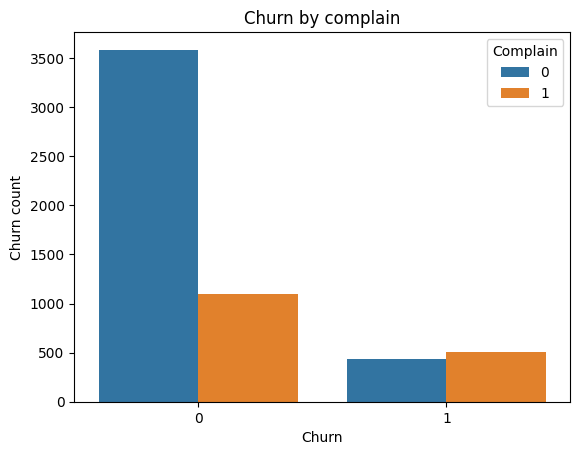

In [13]:
df_churn_complain = df.groupby(['Churn', 'Complain'])['Churn'].count().reset_index(name='Churn count')

sns.barplot(data=df_churn_complain, x='Churn', y='Churn count', hue='Complain')
plt.xlabel('Churn')
plt.ylabel('Churn count')
plt.title('Churn by complain')
plt.show()

Let's see WarehouseToHome factor per churn: Whether distance can result in more churn
- Profile of churn and not churn is similar: majority of users are located closer to warehouse (0~20 distance unit)
- Churn occurs more when the distance between warehouse and home is closer. This indicates that distance might not be a strong indicator

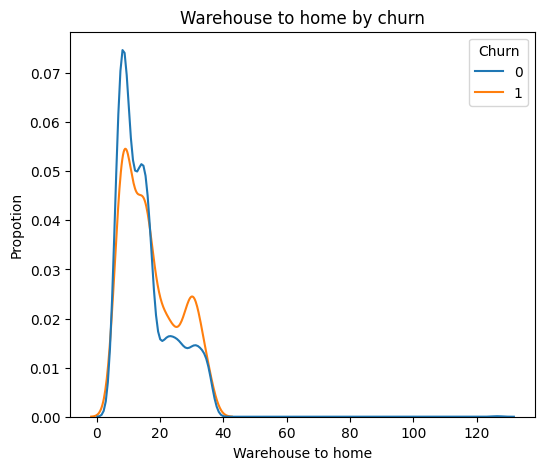

In [14]:
plt.figure(figsize=(6, 5))
sns.kdeplot(data=df, x='WarehouseToHome', hue='Churn', common_norm=False)
plt.xlabel('Warehouse to home')
plt.ylabel('Propotion')
plt.title('Warehouse to home by churn')
plt.show()

Let's see OrderAmountHikeFromlastYear factor per churn: Whether order from last year can give hint of churn
- Profile is similar: People who churn do not show less order from last year

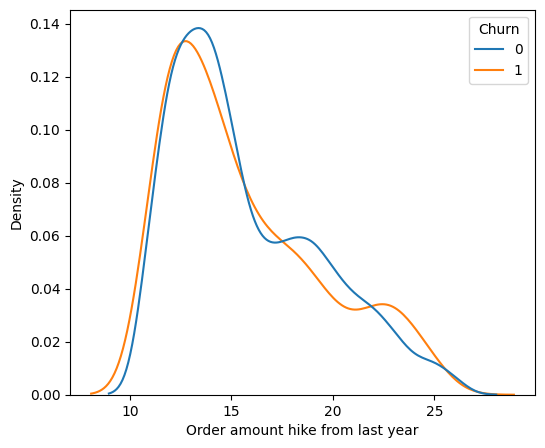

In [15]:
plt.figure(figsize=(6, 5))
sns.kdeplot(data=df, x='OrderAmountHikeFromlastYear', hue='Churn', common_norm=False)
plt.xlabel('Order amount hike from last year')
plt.show()

Let's see OrderCount factor per churn: Whether order from last month drops for people who churn
- No clear drop of order from last month for people who churn

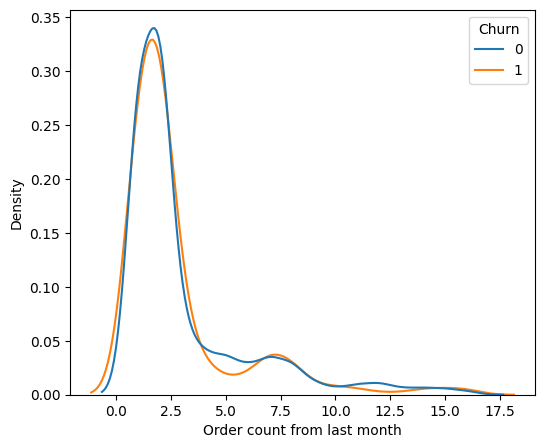

In [16]:
plt.figure(figsize=(6, 5))
sns.kdeplot(data=df, x='OrderCount', hue='Churn', common_norm=False)
plt.xlabel('Order count from last month')
plt.show()

Let's see DaySinceLastOrder factor per churn: Whether people who churn have not placed order for a while
- Profile is similar for both groups: People who churn still place order recently

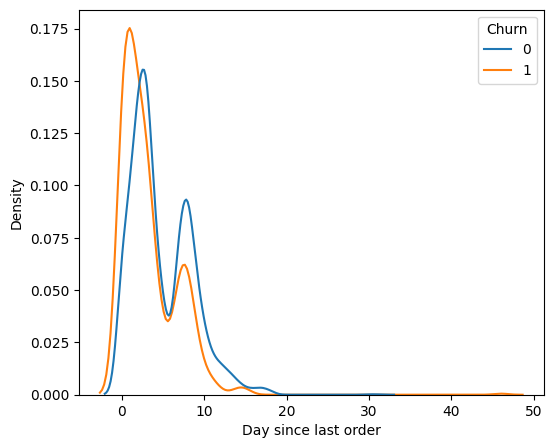

In [17]:
plt.figure(figsize=(6, 5))
sns.kdeplot(data=df, x='DaySinceLastOrder', hue='Churn', common_norm=False)
plt.xlabel('Day since last order')
plt.show()

Calcualate correlation between each numeric columns
- Complain has highest positive correlation and tenure has highest negative correlation  
Note: Correlation analysis will not indicate the combination effect of columns

Tenure                        -0.349408
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154118
OrderCount                    -0.028697
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264
HourSpendOnApp                 0.018675
NumberOfAddress                0.043931
WarehouseToHome                0.076630
CityTier                       0.084703
SatisfactionScore              0.105481
NumberOfDeviceRegistered       0.107939
Complain                       0.250188
Name: Churn, dtype: float64


C:\Users\nanya\AppData\Local\Temp\ipykernel_20868\2549143702.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_corr = df.corr()


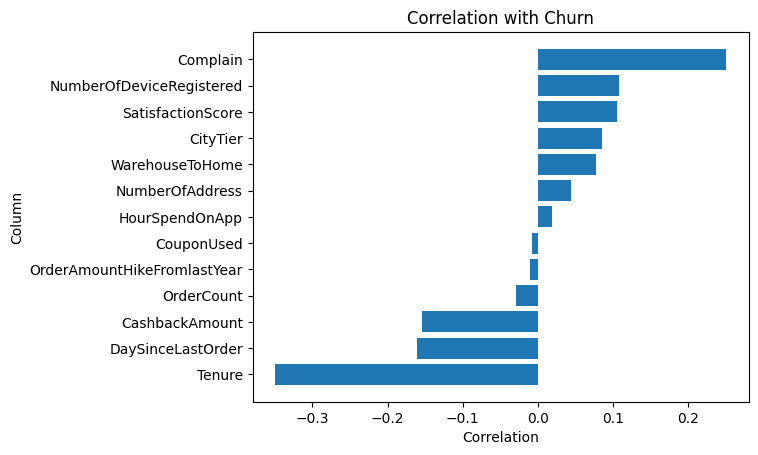

In [18]:
df_corr = df.corr()
corr_with_churn = df_corr.loc['Churn'].sort_values(ascending=True).iloc[:-1]
print(corr_with_churn)
plt.barh(corr_with_churn.index, corr_with_churn.values)
plt.ylabel('Column')
plt.xlabel('Correlation')
plt.title('Correlation with Churn')
plt.show()

## Model training
### Model Choice
Considering classification prediction and dealing with missing value, I will use random forest, XGBoost, LightGBM, and CatBoost
- Random Forest (Parallel tree training/ Deeper tree (longer)
  - Process: train test split --> one hot encoding --> Model training --> Model evaluation
- XGBoost (Sequential tree training/ pruning and regularization (faster compared to RF)
  - Process: train test split --> Model training (enable_categorical=True) --> Model evaluation
- LightGBM (Leaf wise tree training/ Faster compared to XGBoost/ Prone to overfitting)
  - Process: train test split --> Model training (categorical_feature=...) --> Model evaluation
- CatBoost (Symmetric tree structure/ Faster/ Less prone to be overfitting)
  - Process: train test split --> Model training (cat_features=...) --> Model evaluation

### Train test split
- Use 80% for training and 20% for testing

### Preprocess & Training
- Get numeric columns and categorical columns
- One hot encoding for RF. GridSearch for RF
- GridSearch for XGBoost, lightGBM, and catboost

### Train test split

In [19]:
x = df.drop(columns=['Churn'], axis=1)
y = df['Churn']

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(x_train.shape)
print(x_test.shape)
x_train.head()

(4504, 18)
(1126, 18)


,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1787,9.0,Computer,3,16.0,Credit Card,Male,2.0,3,Fashion,1,Single,2,0,14.0,8.0,9.0,7.0,199.80
2147,6.0,Computer,3,13.0,Debit Card,Female,1.0,3,Laptop & Accessory,4,Married,1,0,17.0,0.0,1.0,2.0,143.02
1717,8.0,Mobile Phone,1,15.0,Debit Card,Male,3.0,4,Laptop & Accessory,4,Single,10,0,19.0,0.0,1.0,0.0,165.40
2292,15.0,Mobile Phone,3,11.0,Debit Card,Male,3.0,3,Fashion,4,Single,10,1,19.0,7.0,7.0,7.0,184.46
5578,12.0,Computer,1,13.0,Debit Card,Male,4.0,5,Laptop & Accessory,3,Married,4,0,12.0,3.0,8.0,8.0,178.21


### Preprocess & Training

In [21]:
num_columns = x_train.select_dtypes(include=['number']).columns.tolist()
cat_columns = x_train.select_dtypes(include=['category']).columns.tolist()
print(num_columns)
print(cat_columns)

['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


In [22]:
# Random forest training set-up
cat_transformer = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                           ]
                          )

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_columns),
    ]
)

pipline_rf = Pipeline([('preprocessor_rf', preprocessor_rf), 
                       ('rf_classifier', RandomForestClassifier(n_estimators=500, class_weight='balanced', min_samples_leaf=50, random_state=42)),
                      ]
                     )

param_grid_rf = {
    # 'rf_classifier__n_estimators': [300, 500, 600, 700],
    'rf_classifier__max_depth': [5, 10, 15, 20],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_rf = GridSearchCV(estimator=pipline_rf,
                        param_grid=param_grid_rf,
                        cv=cv,
                        verbose=1,
                        scoring='average_precision',
                        return_train_score=True  # Return training score to judge whjether overfitting or not
                       )


In [25]:
# XBGoost training set-up
neg = df['Churn'].value_counts()[0]
pos = df['Churn'].value_counts()[1]
scale_pos_weight= neg / pos

xgb_classifier = XGBClassifier(n_estimators=500,
                               learning_rate=0.1, 
                               scale_pos_weight=scale_pos_weight, 
                               enable_categorical=True, 
                               min_child_weight=5,
                               subsample=0.8,  # Each tree uses only 80% of data
                               random_state=42
                              )

param_grid_xgb = {
    # 'n_estimators': [300, 500, 600, 700],
    'max_depth': [3, 4, 5, 6, 8],
}

model_xgb = GridSearchCV(estimator=xgb_classifier, 
                         param_grid=param_grid_xgb, 
                         cv=cv, 
                         verbose=1,
                         scoring='average_precision',
                         return_train_score=True  # Return training score to judge whjether overfitting or not
                        )


In [26]:
# LightGBM training set-up
lgbm_classifier = LGBMClassifier(n_estimators=500,
                                 learning_rate=0.1, 
                                 class_weight='balanced', 
                                 min_child_samples=50,
                                 subsample=0.8,
                                 subsample_freq=1,  # Apply subsample every tree to deal with overfitting
                                 random_state=42
                                )

param_grid_lgbm = {
    # 'n_estimators': [300, 500, 600, 700],
    'num_leaves': [20, 25, 30, 40],
}

model_lgbm = GridSearchCV(estimator=lgbm_classifier, 
                          param_grid=param_grid_lgbm, 
                          cv=cv, 
                          verbose=1, 
                          scoring='average_precision',
                          return_train_score=True  # Return training score to judge whjether overfitting or not
                         )

In [27]:
# Catboost training set-up
cb_classifier = CatBoostClassifier(auto_class_weights='Balanced',
                                   min_data_in_leaf=50,
                                   bootstrap_type='Bernoulli',
                                   random_seed=42)

param_grid_cb = {
    # 'iterations': [500, 800, 900],
    'depth': [4, 5, 6, 8],
}

model_cb = GridSearchCV(estimator=cb_classifier, 
                        param_grid=param_grid_cb, 
                        cv=cv, 
                        verbose=1, 
                        scoring='average_precision',
                        return_train_score=True, # Return training score to judge whjether overfitting or not
                       )

In [ ]:
# Model training
models = [model_rf, model_xgb, model_lgbm, model_cb]
for m in models:
    a = time.time()
    if m == model_cb:
        m.fit(x_train,y_train, cat_features=cat_columns)
        print(f'The best parameter setting: {m.best_params_}')
        print(f'The average score of the best parameter setting: {m.best_score_:.4f}')
        print(f'The best estimator: {m.best_estimator_}')
        print(f'Evaluation score between training and validation set: {m.cv_results_}')
        print('\n')
    else:
        m.fit(x_train,y_train)
        print(f'The best parameter setting: {m.best_params_}')
        print(f'The average score of the best parameter setting: {m.best_score_:.4f}')
        print(f'The best estimator: {m.best_estimator_}')
        print(f'Evaluation score between training and validation set: {m.cv_results_}')
        print('\n')  
    b = time.time()
runtime = b - a
print(f'Total runtime: {runtime}s')

349:	learn: 0.1535102	total: 9.89s	remaining: 4.24s
350:	learn: 0.1529447	total: 9.92s	remaining: 4.21s
351:	learn: 0.1527226	total: 9.94s	remaining: 4.18s
352:	learn: 0.1522766	total: 9.97s	remaining: 4.15s
353:	learn: 0.1519672	total: 10s	remaining: 4.13s
354:	learn: 0.1516353	total: 10s	remaining: 4.1s
355:	learn: 0.1511761	total: 10.1s	remaining: 4.07s
356:	learn: 0.1507116	total: 10.1s	remaining: 4.04s
357:	learn: 0.1502585	total: 10.1s	remaining: 4.01s
358:	learn: 0.1497174	total: 10.1s	remaining: 3.98s
359:	learn: 0.1493219	total: 10.2s	remaining: 3.96s
360:	learn: 0.1491130	total: 10.2s	remaining: 3.93s
361:	learn: 0.1485186	total: 10.2s	remaining: 3.9s
362:	learn: 0.1480372	total: 10.3s	remaining: 3.87s
363:	learn: 0.1476856	total: 10.3s	remaining: 3.84s
364:	learn: 0.1472839	total: 10.3s	remaining: 3.81s
365:	learn: 0.1470337	total: 10.3s	remaining: 3.78s
366:	learn: 0.1464531	total: 10.4s	remaining: 3.76s
367:	learn: 0.1458831	total: 10.4s	remaining: 3.73s
368:	learn: 0.1455

## Model evaluation

## Follow-up action recommendation